In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [2]:
df = pd.read_csv('/content/vehicles.csv')

/tmp/ipython-input-872177291.py:1: DtypeWarning: Columns (69,71,72,73,74,75,77,80) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/vehicles.csv')


In [3]:
df.head()

,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
0,14.167143,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
1,27.046364,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
2,11.018889,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
3,27.046364,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
4,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49580 entries, 0 to 49579
Data columns (total 84 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   barrels08        49580 non-null  float64
 1   barrelsA08       49580 non-null  float64
 2   charge120        49580 non-null  float64
 3   charge240        49580 non-null  float64
 4   city08           49580 non-null  int64  
 5   city08U          49580 non-null  float64
 6   cityA08          49580 non-null  int64  
 7   cityA08U         49580 non-null  float64
 8   cityCD           49580 non-null  float64
 9   cityE            49580 non-null  float64
 10  cityUF           49580 non-null  float64
 11  co2              49580 non-null  int64  
 12  co2A             49580 non-null  int64  
 13  co2TailpipeAGpm  49580 non-null  float64
 14  co2TailpipeGpm   49580 non-null  float64
 15  comb08           49580 non-null  int64  
 16  comb08U          49580 non-null  float64
 17  combA08     

In [5]:
df.year.value_counts()

,count
year,
1984,1964
1985,1701
2018,1350
2019,1347
2023,1330
2022,1321
2017,1296
2021,1286
2015,1281


In [6]:
df_filtered = df[df['year'] >= 2000].copy()
display(df_filtered.head())

,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
6210,16.528333,0.0,0.0,0.0,15,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
6212,16.528333,0.0,0.0,0.0,15,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
6213,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
6214,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
6215,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0


In [7]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31603 entries, 6210 to 44032
Data columns (total 84 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   barrels08        31603 non-null  float64
 1   barrelsA08       31603 non-null  float64
 2   charge120        31603 non-null  float64
 3   charge240        31603 non-null  float64
 4   city08           31603 non-null  int64  
 5   city08U          31603 non-null  float64
 6   cityA08          31603 non-null  int64  
 7   cityA08U         31603 non-null  float64
 8   cityCD           31603 non-null  float64
 9   cityE            31603 non-null  float64
 10  cityUF           31603 non-null  float64
 11  co2              31603 non-null  int64  
 12  co2A             31603 non-null  int64  
 13  co2TailpipeAGpm  31603 non-null  float64
 14  co2TailpipeGpm   31603 non-null  float64
 15  comb08           31603 non-null  int64  
 16  comb08U          31603 non-null  float64
 17  combA08       

In [8]:
df_filtered.year.value_counts()

,count
year,
2018,1350
2019,1347
2023,1330
2022,1321
2017,1296
2021,1286
2015,1281
2024,1277
2025,1272


In [9]:
df_filtered.year.count()

np.int64(31603)

In [10]:
df_filtered.drop('id', axis=1, inplace=True)

In [11]:
df_filtered.isna().sum()

,0
barrels08,0
barrelsA08,0
charge120,0
charge240,0
city08,0
...,...
modifiedOn,0
startStop,13722
phevCity,0
phevHwy,0


In [12]:
df_filtered.drop('engId', axis=1, inplace=True)

In [13]:
df_filtered.drop('fuelCost08', axis=1, inplace=True)

In [14]:
df_filtered.drop('fuelCostA08', axis=1, inplace=True)

In [15]:
df_filtered.drop('youSaveSpend', axis=1, inplace=True)

In [16]:
df_filtered.drop('mpgData', axis=1, inplace=True)

In [17]:
df_filtered.drop('mfrCode', axis=1, inplace=True)

In [18]:
df_filtered.drop('createdOn', axis=1, inplace=True)

In [19]:
df_filtered.drop('modifiedOn', axis=1, inplace=True)

In [20]:
df_filtered.drop('trans_dscr', axis=1, inplace=True)

In [21]:
df_filtered.drop('c240Dscr', axis=1, inplace=True)

In [22]:
df_filtered.drop('c240bDscr', axis=1, inplace=True)

In [23]:
df_filtered.drop('startStop', axis=1, inplace=True)

In [24]:
df_filtered.drop('evMotor', axis=1, inplace=True)

In [25]:
df_filtered.drop('rangeA', axis=1, inplace=True)

In [26]:
df_filtered.drop('fuelType2', axis=1, inplace=True)

In [27]:
df_filtered.drop('atvType', axis=1, inplace=True)

In [28]:
df_filtered.drop('sCharger', axis=1, inplace=True)

In [29]:
df_filtered.drop('tCharger', axis=1, inplace=True)

In [30]:
df_filtered.drop('guzzler', axis=1, inplace=True)

In [31]:
df_filtered.drop('eng_dscr', axis=1, inplace=True)

In [32]:
df_filtered.drop('model', axis=1, inplace=True)

In [33]:
df_filtered.drop('VClass', axis=1, inplace=True)

In [34]:
df_filtered.drop('fuelType', axis=1, inplace=True)

In [35]:
df_filtered.drop('make', axis=1, inplace=True)

In [36]:
df_filtered.drop('trany', axis=1, inplace=True)

In [37]:
df_filtered = df_filtered[df_filtered['fuelType1'] != 'Hydrogen'].copy()
display(df_filtered.head())

,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,UCity,UCityA,UHighway,UHighwayA,year,baseModel,charge240b,phevCity,phevHwy,phevComb
6210,16.528333,0.0,0.0,0.0,15,0.0,0,0.0,0.0,0.0,...,19.2343,0.0,30.1499,0.0,2000,NSX,0.0,0,0,0
6212,16.528333,0.0,0.0,0.0,15,0.0,0,0.0,0.0,0.0,...,19.0000,0.0,30.4000,0.0,2000,NSX,0.0,0,0,0
6213,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,21.1000,0.0,32.7000,0.0,2000,M,0.0,0,0,0
6214,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,20.9000,0.0,33.6000,0.0,2000,Z3,0.0,0,0,0
6215,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,21.0220,0.0,32.8870,0.0,2000,Z3,0.0,0,0,0


In [38]:
drive_counts = df_filtered[df_filtered['fuelType1'] == 'Hydrogen']['fuelType1'].count()
print(f"Number of vehicles with '4-Wheel or All-Wheel Drive': {drive_counts}")

Number of vehicles with '4-Wheel or All-Wheel Drive': 0


In [39]:
df_filtered = df_filtered[df_filtered['drive'] != '2-Wheel Drive'].copy()
display(df_filtered.head())

,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,UCity,UCityA,UHighway,UHighwayA,year,baseModel,charge240b,phevCity,phevHwy,phevComb
6210,16.528333,0.0,0.0,0.0,15,0.0,0,0.0,0.0,0.0,...,19.2343,0.0,30.1499,0.0,2000,NSX,0.0,0,0,0
6212,16.528333,0.0,0.0,0.0,15,0.0,0,0.0,0.0,0.0,...,19.0000,0.0,30.4000,0.0,2000,NSX,0.0,0,0,0
6213,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,21.1000,0.0,32.7000,0.0,2000,M,0.0,0,0,0
6214,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,20.9000,0.0,33.6000,0.0,2000,Z3,0.0,0,0,0
6215,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,21.0220,0.0,32.8870,0.0,2000,Z3,0.0,0,0,0


In [40]:
drive_counts = df_filtered[df_filtered['drive'] == '2-Wheel Drive']['drive'].count()
print(f"Number of vehicles with '2-Wheel Drive': {drive_counts}")

Number of vehicles with '2-Wheel Drive': 0


In [41]:
df_filtered.fuelType1.unique()

array(['Premium Gasoline', 'Regular Gasoline', 'Diesel', 'Natural Gas',
       'Electricity', 'Midgrade Gasoline'], dtype=object)

In [42]:
df_filtered.drive.unique()

array(['Rear-Wheel Drive', 'Front-Wheel Drive',
       '4-Wheel or All-Wheel Drive', nan, 'All-Wheel Drive',
       '4-Wheel Drive', 'Part-time 4-Wheel Drive'], dtype=object)

In [43]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31550 entries, 6210 to 44032
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   barrels08        31550 non-null  float64
 1   barrelsA08       31550 non-null  float64
 2   charge120        31550 non-null  float64
 3   charge240        31550 non-null  float64
 4   city08           31550 non-null  int64  
 5   city08U          31550 non-null  float64
 6   cityA08          31550 non-null  int64  
 7   cityA08U         31550 non-null  float64
 8   cityCD           31550 non-null  float64
 9   cityE            31550 non-null  float64
 10  cityUF           31550 non-null  float64
 11  co2              31550 non-null  int64  
 12  co2A             31550 non-null  int64  
 13  co2TailpipeAGpm  31550 non-null  float64
 14  co2TailpipeGpm   31550 non-null  float64
 15  comb08           31550 non-null  int64  
 16  comb08U          31550 non-null  float64
 17  combA08       

In [44]:
df_filtered.displ.unique()

array([3. , 3.2, 2.8, 2.5, 4.9, 5.7, 8. , 3.6, 5.5, 1. , 2. , 3.5, 1.8,
       5. , 6. , 2.3, 2.7, 5.9, 4. , 4.3, 3.4, 4.6, 6.7, 3.8, 2.2, 2.4,
       1.3, 5.4, 1.6, 1.5, 1.9, 4.4, 4.2, 3.1, 4.1, 3.9, 2.9, 4.8, 5.3,
       4.7, 5.2, 3.3, nan, 6.8, 1.7, 2.6, 5.8, 6.2, 4.5, 3.7, 8.3, 5.6,
       6.1, 7. , 6.5, 8.4, 6.3, 6.6, 1.4, 6.4, 1.2, 2.1, 0.6, 0. , 0.9])

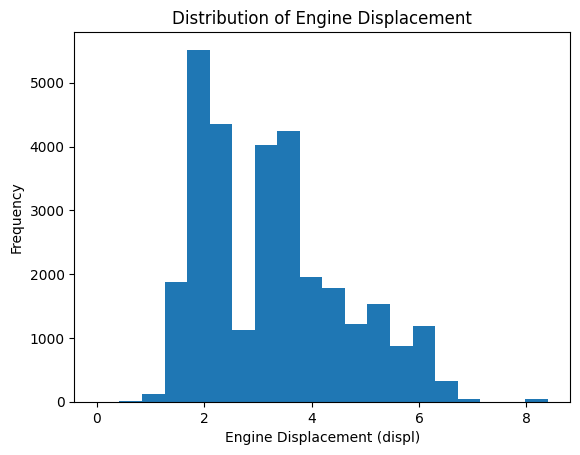

In [45]:
plt.hist(df_filtered['displ'].dropna(), bins=20)
plt.xlabel('Engine Displacement (displ)')
plt.ylabel('Frequency')
plt.title('Distribution of Engine Displacement')
plt.show()

In [46]:
mean_displ = df_filtered['displ'].mean()
df_filtered['displ'].fillna(mean_displ, inplace=True)

/tmp/ipython-input-652089259.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtered['displ'].fillna(mean_displ, inplace=True)


In [47]:
df_filtered.displ.isna().sum()

np.int64(0)

In [48]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31550 entries, 6210 to 44032
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   barrels08        31550 non-null  float64
 1   barrelsA08       31550 non-null  float64
 2   charge120        31550 non-null  float64
 3   charge240        31550 non-null  float64
 4   city08           31550 non-null  int64  
 5   city08U          31550 non-null  float64
 6   cityA08          31550 non-null  int64  
 7   cityA08U         31550 non-null  float64
 8   cityCD           31550 non-null  float64
 9   cityE            31550 non-null  float64
 10  cityUF           31550 non-null  float64
 11  co2              31550 non-null  int64  
 12  co2A             31550 non-null  int64  
 13  co2TailpipeAGpm  31550 non-null  float64
 14  co2TailpipeGpm   31550 non-null  float64
 15  comb08           31550 non-null  int64  
 16  comb08U          31550 non-null  float64
 17  combA08       

In [49]:
df_filtered.dropna(subset=['drive'], inplace=True)

In [50]:
df_filtered.drive.isna().sum()

np.int64(0)

In [51]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31546 entries, 6210 to 44032
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   barrels08        31546 non-null  float64
 1   barrelsA08       31546 non-null  float64
 2   charge120        31546 non-null  float64
 3   charge240        31546 non-null  float64
 4   city08           31546 non-null  int64  
 5   city08U          31546 non-null  float64
 6   cityA08          31546 non-null  int64  
 7   cityA08U         31546 non-null  float64
 8   cityCD           31546 non-null  float64
 9   cityE            31546 non-null  float64
 10  cityUF           31546 non-null  float64
 11  co2              31546 non-null  int64  
 12  co2A             31546 non-null  int64  
 13  co2TailpipeAGpm  31546 non-null  float64
 14  co2TailpipeGpm   31546 non-null  float64
 15  comb08           31546 non-null  int64  
 16  comb08U          31546 non-null  float64
 17  combA08       

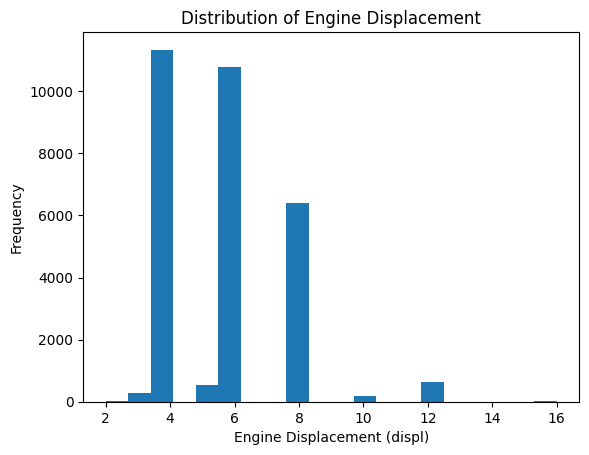

In [52]:
plt.hist(df_filtered['cylinders'], bins=20)
plt.xlabel('Engine Displacement (displ)')
plt.ylabel('Frequency')
plt.title('Distribution of Engine Displacement')
plt.show()

In [53]:
df_filtered.dropna(subset=['cylinders'], inplace=True)

In [54]:
df_filtered.drive.isna().sum()

np.int64(0)

In [55]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30240 entries, 6210 to 44009
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   barrels08        30240 non-null  float64
 1   barrelsA08       30240 non-null  float64
 2   charge120        30240 non-null  float64
 3   charge240        30240 non-null  float64
 4   city08           30240 non-null  int64  
 5   city08U          30240 non-null  float64
 6   cityA08          30240 non-null  int64  
 7   cityA08U         30240 non-null  float64
 8   cityCD           30240 non-null  float64
 9   cityE            30240 non-null  float64
 10  cityUF           30240 non-null  float64
 11  co2              30240 non-null  int64  
 12  co2A             30240 non-null  int64  
 13  co2TailpipeAGpm  30240 non-null  float64
 14  co2TailpipeGpm   30240 non-null  float64
 15  comb08           30240 non-null  int64  
 16  comb08U          30240 non-null  float64
 17  combA08       

In [56]:
df_temp = df_filtered.copy()
df_temp = df_temp.drop('baseModel', axis=1)
df_temp = df_temp.drop('drive', axis=1)
df_temp = df_temp.drop('fuelType1', axis=1)


In [57]:
correlation_matrix = df_temp.corr()

# Plot the correlation matrix using seaborn's heatmap
plt.figure(figsize=(220, 200))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [58]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30240 entries, 6210 to 44009
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   barrels08        30240 non-null  float64
 1   barrelsA08       30240 non-null  float64
 2   charge120        30240 non-null  float64
 3   charge240        30240 non-null  float64
 4   city08           30240 non-null  int64  
 5   city08U          30240 non-null  float64
 6   cityA08          30240 non-null  int64  
 7   cityA08U         30240 non-null  float64
 8   cityCD           30240 non-null  float64
 9   cityE            30240 non-null  float64
 10  cityUF           30240 non-null  float64
 11  co2              30240 non-null  int64  
 12  co2A             30240 non-null  int64  
 13  co2TailpipeAGpm  30240 non-null  float64
 14  co2TailpipeGpm   30240 non-null  float64
 15  comb08           30240 non-null  int64  
 16  comb08U          30240 non-null  float64
 17  combA08       

In [59]:
df_temp.corr()['comb08'].sort_values(ascending=False)

,comb08
comb08,1.000000
city08,0.985974
UCity,0.978659
highway08,0.963942
UHighway,0.961141
city08U,0.636668
comb08U,0.608201
feScore,0.562896
highway08U,0.561320
ghgScore,0.559621


In [60]:
df_filtered.drop('highway08U', axis=1, inplace=True)
df_filtered.drop('highwayA08', axis=1, inplace=True)
df_filtered.drop('cityA08', axis=1, inplace=True)
df_filtered.drop('city08U', axis=1, inplace=True)
df_filtered.drop('comb08U', axis=1, inplace=True)
df_filtered.drop('combA08', axis=1, inplace=True)
df_filtered.drop('rangeCity', axis=1, inplace=True)
df_filtered.drop('rangeHwy', axis=1, inplace=True)

In [61]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30240 entries, 6210 to 44009
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   barrels08        30240 non-null  float64
 1   barrelsA08       30240 non-null  float64
 2   charge120        30240 non-null  float64
 3   charge240        30240 non-null  float64
 4   city08           30240 non-null  int64  
 5   cityA08U         30240 non-null  float64
 6   cityCD           30240 non-null  float64
 7   cityE            30240 non-null  float64
 8   cityUF           30240 non-null  float64
 9   co2              30240 non-null  int64  
 10  co2A             30240 non-null  int64  
 11  co2TailpipeAGpm  30240 non-null  float64
 12  co2TailpipeGpm   30240 non-null  float64
 13  comb08           30240 non-null  int64  
 14  combA08U         30240 non-null  float64
 15  combE            30240 non-null  float64
 16  combinedCD       30240 non-null  float64
 17  combinedUF    

In [62]:
df_temp = df_filtered.copy()
df_temp = df_temp.drop('baseModel', axis=1)
df_temp = df_temp.drop('drive', axis=1)
df_temp = df_temp.drop('fuelType1', axis=1)
df_temp.corr()['comb08'].sort_values(ascending=False)

,comb08
comb08,1.000000
city08,0.985974
UCity,0.978659
highway08,0.963942
UHighway,0.961141
feScore,0.562896
ghgScore,0.559621
year,0.304011
hpv,0.290099
pv4,0.263250


In [63]:
df_filtered.drop('UCity', axis=1, inplace=True)
df_filtered.drop('UHighway', axis=1, inplace=True)
df_filtered.drop('feScore', axis=1, inplace=True)
df_filtered.drop('ghgScore', axis=1, inplace=True)
df_filtered.drop('hpv', axis=1, inplace=True)
df_filtered.drop('pv4', axis=1, inplace=True)
df_filtered.drop('hlv', axis=1, inplace=True)
df_filtered.drop('lv4', axis=1, inplace=True)
df_filtered.drop('phevCity', axis=1, inplace=True)
df_filtered.drop('phevComb', axis=1, inplace=True)
df_filtered.drop('phevHwy', axis=1, inplace=True)
df_filtered.drop('cityA08U', axis=1, inplace=True)
df_filtered.drop('UCityA', axis=1, inplace=True)
df_filtered.drop('combA08U', axis=1, inplace=True)

In [64]:
df_temp = df_filtered.copy()
df_temp = df_temp.drop('baseModel', axis=1)
df_temp = df_temp.drop('drive', axis=1)
df_temp = df_temp.drop('fuelType1', axis=1)
df_temp.corr()['city08'].sort_values(ascending=False)

,city08
city08,1.000000
comb08,0.985974
highway08,0.914537
year,0.304590
range,0.193674
cityUF,0.191817
combinedUF,0.188655
highwayA08U,0.184536
highwayUF,0.184235
rangeCityA,0.180914


In [65]:
df_filtered.drop('co2TailpipeAGpm', axis=1, inplace=True)
df_filtered.drop('barrelsA08', axis=1, inplace=True)
df_filtered.drop('co2A', axis=1, inplace=True)
df_filtered.drop('pv2', axis=1, inplace=True)
df_filtered.drop('lv2', axis=1, inplace=True)
df_filtered.drop('highwayCD', axis=1, inplace=True)
df_filtered.drop('combinedCD', axis=1, inplace=True)
df_filtered.drop('ghgScoreA', axis=1, inplace=True)
df_filtered.drop('cityCD', axis=1, inplace=True)
df_filtered.drop('charge120', axis=1, inplace=True)
df_filtered.drop('charge240b', axis=1, inplace=True)
df_filtered.drop('co2', axis=1, inplace=True)

In [66]:
df_temp = df_filtered.copy()
df_temp = df_temp.drop('baseModel', axis=1)
df_temp = df_temp.drop('drive', axis=1)
df_temp = df_temp.drop('fuelType1', axis=1)
df_temp.corr()['city08'].sort_values(ascending=False)

,city08
city08,1.000000
comb08,0.985974
highway08,0.914537
year,0.304590
range,0.193674
cityUF,0.191817
combinedUF,0.188655
highwayA08U,0.184536
highwayUF,0.184235
rangeCityA,0.180914


In [67]:
df_filtered.drop('UHighwayA', axis=1, inplace=True)
df_filtered.drop('cityE', axis=1, inplace=True)
df_filtered.drop('combE', axis=1, inplace=True)
df_filtered.drop('highwayE', axis=1, inplace=True)
df_filtered.drop('charge240', axis=1, inplace=True)
df_filtered.drop('phevBlended', axis=1, inplace=True)
df_filtered.drop('rangeHwyA', axis=1, inplace=True)
df_filtered.drop('rangeCityA', axis=1, inplace=True)
df_filtered.drop('highwayUF', axis=1, inplace=True)
df_filtered.drop('highwayA08U', axis=1, inplace=True)
df_filtered.drop('combinedUF', axis=1, inplace=True)
df_filtered.drop('cityUF', axis=1, inplace=True)

In [68]:
df_temp = df_filtered.copy()
df_temp = df_temp.drop('baseModel', axis=1)
df_temp = df_temp.drop('drive', axis=1)
df_temp = df_temp.drop('fuelType1', axis=1)
df_temp.corr()['city08'].sort_values(ascending=False)

,city08
city08,1.000000
comb08,0.985974
highway08,0.914537
year,0.304590
range,0.193674
cylinders,-0.671315
displ,-0.697849
barrels08,-0.860246
co2TailpipeGpm,-0.877284


In [69]:
df_filtered.head()

,barrels08,city08,co2TailpipeGpm,comb08,cylinders,displ,drive,fuelType1,highway08,range,year,baseModel
6210,16.528333,15,493.722222,18,6.0,3.0,Rear-Wheel Drive,Premium Gasoline,22,0,2000,NSX
6212,16.528333,15,493.722222,18,6.0,3.2,Rear-Wheel Drive,Premium Gasoline,22,0,2000,NSX
6213,15.658421,17,467.736842,19,6.0,3.2,Rear-Wheel Drive,Premium Gasoline,23,0,2000,M
6214,15.658421,17,467.736842,19,6.0,2.8,Rear-Wheel Drive,Premium Gasoline,24,0,2000,Z3
6215,15.658421,17,467.736842,19,6.0,2.8,Rear-Wheel Drive,Premium Gasoline,24,0,2000,Z3


In [70]:
df_filtered.fuelType1.unique()

array(['Premium Gasoline', 'Regular Gasoline', 'Diesel', 'Natural Gas',
       'Midgrade Gasoline'], dtype=object)

In [71]:
df_filtered.drive.unique()

array(['Rear-Wheel Drive', 'Front-Wheel Drive',
       '4-Wheel or All-Wheel Drive', 'All-Wheel Drive', '4-Wheel Drive',
       'Part-time 4-Wheel Drive'], dtype=object)

In [72]:
df_filtered.drop('drive', axis=1, inplace=True)

In [73]:
#droping for features merging
df_filtered.drop('co2TailpipeGpm', axis=1, inplace=True)
df_filtered.drop('range', axis=1, inplace=True)
df_filtered.drop('barrels08', axis=1, inplace=True)

In [74]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30240 entries, 6210 to 44009
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city08     30240 non-null  int64  
 1   comb08     30240 non-null  int64  
 2   cylinders  30240 non-null  float64
 3   displ      30240 non-null  float64
 4   fuelType1  30240 non-null  object 
 5   highway08  30240 non-null  int64  
 6   year       30240 non-null  int64  
 7   baseModel  30240 non-null  object 
dtypes: float64(2), int64(4), object(2)
memory usage: 2.1+ MB


In [75]:
df_filtered.to_csv('S&S cleaned DS Fuel Consumption.csv', index=False)
#save csv

In [76]:
# df_temp = df_filtered.copy()
# df_temp = df_temp.drop('baseModel', axis=1)
# df_temp.corr()['city08'].sort_values(ascending=False)

In [77]:
df_new = pd.read_csv('/content/cleaned_fuel_consumption_ratings.csv')
display(df_new.head())

,Model year,Model,Engine size (L),Cylinders,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km)
0,2015,ILX,2.0,4,Premium gasoline,9.7,6.7,8.3
1,2015,ILX,2.4,4,Premium gasoline,10.8,7.4,9.3
2,2015,ILX Hybrid,1.5,4,Premium gasoline,6.0,6.1,6.1
3,2015,MDX SH-AWD,3.5,6,Premium gasoline,12.7,9.1,11.1
4,2015,RDX AWD,3.5,6,Premium gasoline,12.1,8.7,10.6


In [78]:
print("Columns in df_filtered:", df_filtered.columns)
print("Columns in df_new:", df_new.columns)

Columns in df_filtered: Index(['city08', 'comb08', 'cylinders', 'displ', 'fuelType1', 'highway08',
       'year', 'baseModel'],
      dtype='object')
Columns in df_new: Index(['Model year', 'Model', 'Engine size (L)', 'Cylinders', 'Fuel type',
       'City (L/100 km)', 'Highway (L/100 km)', 'Combined (L/100 km)'],
      dtype='object')


In [79]:
df_filtered.isna().sum()

,0
city08,0
comb08,0
cylinders,0
displ,0
fuelType1,0
highway08,0
year,0
baseModel,0


In [80]:
df_new.isna().sum()

,0
Model year,0
Model,0
Engine size (L),0
Cylinders,0
Fuel type,0
City (L/100 km),0
Highway (L/100 km),0
Combined (L/100 km),0


In [81]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10058 entries, 0 to 10057
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model year           10058 non-null  int64  
 1   Model                10058 non-null  object 
 2   Engine size (L)      10058 non-null  float64
 3   Cylinders            10058 non-null  int64  
 4   Fuel type            10058 non-null  object 
 5   City (L/100 km)      10058 non-null  float64
 6   Highway (L/100 km)   10058 non-null  float64
 7   Combined (L/100 km)  10058 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 628.8+ KB


In [82]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30240 entries, 6210 to 44009
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city08     30240 non-null  int64  
 1   comb08     30240 non-null  int64  
 2   cylinders  30240 non-null  float64
 3   displ      30240 non-null  float64
 4   fuelType1  30240 non-null  object 
 5   highway08  30240 non-null  int64  
 6   year       30240 non-null  int64  
 7   baseModel  30240 non-null  object 
dtypes: float64(2), int64(4), object(2)
memory usage: 2.1+ MB


In [83]:
df_filtered_renamed = df_filtered.rename(columns={
    'year': 'Model year',
    'baseModel': 'Model',
    'displ': 'Engine size (L)',
    'cylinders': 'Cylinders',
    'fuelType1': 'Fuel type',
    'city08': 'City (L/100 km)',
    'highway08': 'Highway (L/100 km)',
    'comb08': 'Combined (L/100 km)'
})
display(df_filtered_renamed.head())

,City (L/100 km),Combined (L/100 km),Cylinders,Engine size (L),Fuel type,Highway (L/100 km),Model year,Model
6210,15,18,6.0,3.0,Premium Gasoline,22,2000,NSX
6212,15,18,6.0,3.2,Premium Gasoline,22,2000,NSX
6213,17,19,6.0,3.2,Premium Gasoline,23,2000,M
6214,17,19,6.0,2.8,Premium Gasoline,24,2000,Z3
6215,17,19,6.0,2.8,Premium Gasoline,24,2000,Z3


In [84]:
df_concatenated = pd.concat([df_filtered_renamed, df_new], ignore_index=True)
display(df_concatenated.head())

,City (L/100 km),Combined (L/100 km),Cylinders,Engine size (L),Fuel type,Highway (L/100 km),Model year,Model
0,15.0,18.0,6.0,3.0,Premium Gasoline,22.0,2000,NSX
1,15.0,18.0,6.0,3.2,Premium Gasoline,22.0,2000,NSX
2,17.0,19.0,6.0,3.2,Premium Gasoline,23.0,2000,M
3,17.0,19.0,6.0,2.8,Premium Gasoline,24.0,2000,Z3
4,17.0,19.0,6.0,2.8,Premium Gasoline,24.0,2000,Z3


In [85]:
# Convert 'Fuel type' to lowercase before encoding
df_concatenated['Fuel type'] = df_concatenated['Fuel type'].str.lower()

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df_concatenated[['Fuel type']])

# Create a DataFrame from the encoded data with appropriate index and columns
encoded_df = pd.DataFrame(encoded, index=df_concatenated.index, columns=encoder.get_feature_names_out(['Fuel type']))

# Concatenate the original DataFrame (without 'fuelType1') and the encoded DataFrame
df_concatenated = pd.concat([df_concatenated.drop('Fuel type', axis=1), encoded_df], axis=1)

display(df_concatenated.head())

,City (L/100 km),Combined (L/100 km),Cylinders,Engine size (L),Highway (L/100 km),Model year,Model,Fuel type_diesel,Fuel type_e85,Fuel type_midgrade gasoline,Fuel type_natural gas,Fuel type_premium gasoline,Fuel type_regular gasoline
0,15.0,18.0,6.0,3.0,22.0,2000,NSX,0.0,0.0,0.0,0.0,1.0,0.0
1,15.0,18.0,6.0,3.2,22.0,2000,NSX,0.0,0.0,0.0,0.0,1.0,0.0
2,17.0,19.0,6.0,3.2,23.0,2000,M,0.0,0.0,0.0,0.0,1.0,0.0
3,17.0,19.0,6.0,2.8,24.0,2000,Z3,0.0,0.0,0.0,0.0,1.0,0.0
4,17.0,19.0,6.0,2.8,24.0,2000,Z3,0.0,0.0,0.0,0.0,1.0,0.0


In [86]:
df_concatenated.info()
display(df_concatenated.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40298 entries, 0 to 40297
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   City (L/100 km)              40298 non-null  float64
 1   Combined (L/100 km)          40298 non-null  float64
 2   Cylinders                    40298 non-null  float64
 3   Engine size (L)              40298 non-null  float64
 4   Highway (L/100 km)           40298 non-null  float64
 5   Model year                   40298 non-null  int64  
 6   Model                        40298 non-null  object 
 7   Fuel type_diesel             40298 non-null  float64
 8   Fuel type_e85                40298 non-null  float64
 9   Fuel type_midgrade gasoline  40298 non-null  float64
 10  Fuel type_natural gas        40298 non-null  float64
 11  Fuel type_premium gasoline   40298 non-null  float64
 12  Fuel type_regular gasoline   40298 non-null  float64
dtypes: float64(11), 

,City (L/100 km),Combined (L/100 km),Cylinders,Engine size (L),Highway (L/100 km),Model year,Model,Fuel type_diesel,Fuel type_e85,Fuel type_midgrade gasoline,Fuel type_natural gas,Fuel type_premium gasoline,Fuel type_regular gasoline
0,15.0,18.0,6.0,3.0,22.0,2000,NSX,0.0,0.0,0.0,0.0,1.0,0.0
1,15.0,18.0,6.0,3.2,22.0,2000,NSX,0.0,0.0,0.0,0.0,1.0,0.0
2,17.0,19.0,6.0,3.2,23.0,2000,M,0.0,0.0,0.0,0.0,1.0,0.0
3,17.0,19.0,6.0,2.8,24.0,2000,Z3,0.0,0.0,0.0,0.0,1.0,0.0
4,17.0,19.0,6.0,2.8,24.0,2000,Z3,0.0,0.0,0.0,0.0,1.0,0.0


In [87]:
df_concatenated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40298 entries, 0 to 40297
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   City (L/100 km)              40298 non-null  float64
 1   Combined (L/100 km)          40298 non-null  float64
 2   Cylinders                    40298 non-null  float64
 3   Engine size (L)              40298 non-null  float64
 4   Highway (L/100 km)           40298 non-null  float64
 5   Model year                   40298 non-null  int64  
 6   Model                        40298 non-null  object 
 7   Fuel type_diesel             40298 non-null  float64
 8   Fuel type_e85                40298 non-null  float64
 9   Fuel type_midgrade gasoline  40298 non-null  float64
 10  Fuel type_natural gas        40298 non-null  float64
 11  Fuel type_premium gasoline   40298 non-null  float64
 12  Fuel type_regular gasoline   40298 non-null  float64
dtypes: float64(11), 

In [88]:
numeric_cols = df_concatenated.select_dtypes(include=np.number).columns
correlation_matrix = df_concatenated[numeric_cols].corr()['City (L/100 km)']
print("Correlation with City (L/100 km):")
print(correlation_matrix)

Correlation with City (L/100 km):
City (L/100 km)                1.000000
Combined (L/100 km)            0.965505
Cylinders                     -0.346571
Engine size (L)               -0.360786
Highway (L/100 km)             0.859858
Model year                     0.054420
Fuel type_diesel               0.047621
Fuel type_e85                  0.024927
Fuel type_midgrade gasoline   -0.024423
Fuel type_natural gas         -0.007253
Fuel type_premium gasoline    -0.111360
Fuel type_regular gasoline     0.097451
Name: City (L/100 km), dtype: float64


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Drop the 'Model' column as it's not suitable for direct use in the model
df_model = df_concatenated.drop('Model', axis=1)

# Define features (X) and target (y)
X = df_model.drop(['City (L/100 km)', 'Highway (L/100 km)'], axis=1)
y = df_model[['City (L/100 km)', 'Highway (L/100 km)']]

# Normalize specified columns using MinMaxScaler
scaler = MinMaxScaler()
X["Model year"] = scaler.fit_transform(X[["Model year"]])
X["Engine size (L)"] = scaler.fit_transform(X[["Engine size (L)"]])
X["Cylinders"] = scaler.fit_transform(X[["Cylinders"]])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Mean Squared Error: 3.50
Root Mean Squared Error: 1.87
R-squared: 0.94


In [90]:
X.columns

Index(['Combined (L/100 km)', 'Cylinders', 'Engine size (L)', 'Model year',
       'Fuel type_diesel', 'Fuel type_e85', 'Fuel type_midgrade gasoline',
       'Fuel type_natural gas', 'Fuel type_premium gasoline',
       'Fuel type_regular gasoline'],
      dtype='object')

In [91]:
y.columns

Index(['City (L/100 km)', 'Highway (L/100 km)'], dtype='object')

# Task
LGBM, XGBoost, and Random Forest models will be initialized, trained, and evaluated using the scaled training data (X_train_scaled, y_train).

## Train LGBM Model

### Subtask:
Initialize, train, and evaluate a LightGBM Regressor model on the scaled training data (X_train_scaled, y_train).


**Reasoning**:
The subtask requires initializing, training, and evaluating a LightGBM Regressor model. This involves importing the necessary class, fitting the model to the scaled training data, making predictions on the scaled test data, and then calculating the Mean Squared Error, Root Mean Squared Error, and R-squared to evaluate its performance.



In [93]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

# Initialize the base LGBMRegressor model
base_lgbm = LGBMRegressor(random_state=42)

# Wrap the LGBMRegressor for multi-output regression
lgbm_model = MultiOutputRegressor(estimator=base_lgbm)

# Train the MultiOutputRegressor model
lgbm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluate the model for multi-output regression
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm, multioutput='uniform_average')
rmse_lgbm = np.sqrt(mse_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm, multioutput='uniform_average')

print(f"LightGBM Mean Squared Error: {mse_lgbm:.2f}")
print(f"LightGBM Root Mean Squared Error: {rmse_lgbm:.2f}")
print(f"LightGBM R-squared: {r2_lgbm:.2f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000841 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 301
[LightGBM] [Info] Number of data points in the train set: 28208, number of used features: 10
[LightGBM] [Info] Start training from score 17.461695
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000594 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 301
[LightGBM] [Info] Number of data points in the train set: 28208, number of used features: 10
[LightGBM] [Info] Start training from score 21.544668
LightGBM Mean Squared Error:

**Reasoning**:
Following the pattern of evaluating previous models, I will now evaluate the LightGBM model on the training set to compare its performance with the test set performance.



In [94]:
y_train_pred_lgbm = lgbm_model.predict(X_train)
r2_train_lgbm = r2_score(y_train, y_train_pred_lgbm)

print(f"LightGBM R-squared on the training set: {r2_train_lgbm:.2f}")
print(f"LightGBM R-squared on the testing set: {r2_lgbm:.2f}")

LightGBM R-squared on the training set: 0.99
LightGBM R-squared on the testing set: 0.99


**Reasoning**:
The next logical step in the task is to initialize, train, and evaluate an XGBoost Regressor model, similar to how the LightGBM model was handled.



In [95]:
from xgboost import XGBRegressor

# Initialize and train the XGBRegressor model
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")
print(f"XGBoost Root Mean Squared Error: {rmse_xgb:.2f}")
print(f"XGBoost R-squared: {r2_xgb:.2f}")

XGBoost Mean Squared Error: 0.63
XGBoost Root Mean Squared Error: 0.80
XGBoost R-squared: 0.99


**Reasoning**:
Following the pattern of evaluating previous models, I will now evaluate the XGBoost model on the training set to compare its performance with the test set performance.



In [96]:
y_train_pred_xgb = xgb_model.predict(X_train)
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)

print(f"XGBoost R-squared on the training set: {r2_train_xgb:.2f}")
print(f"XGBoost R-squared on the testing set: {r2_xgb:.2f}")

XGBoost R-squared on the training set: 0.99
XGBoost R-squared on the testing set: 0.99


**Reasoning**:
The final step in the main task is to initialize, train, and evaluate a Random Forest Regressor model, following the same evaluation process used for the LGBM and XGBoost models.



In [97]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest Root Mean Squared Error: {rmse_rf:.2f}")
print(f"Random Forest R-squared: {r2_rf:.2f}")

Random Forest Mean Squared Error: 0.64
Random Forest Root Mean Squared Error: 0.80
Random Forest R-squared: 0.99


**Reasoning**:
Following the pattern of evaluating previous models, I will now evaluate the Random Forest model on the training set to compare its performance with the test set performance.



In [98]:
y_train_pred_rf = rf_model.predict(X_train)
r2_train_rf = r2_score(y_train, y_train_pred_rf)

print(f"Random Forest R-squared on the training set: {r2_train_rf:.2f}")
print(f"Random Forest R-squared on the testing set: {r2_rf:.2f}")

Random Forest R-squared on the training set: 0.99
Random Forest R-squared on the testing set: 0.99


In [99]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# User input data
new_data_input = {
    'Model year': 2023,
    'Engine size (L)': 3.0,
    'Cylinders': 6.0,
    'Combined (L/100 km)': 10.8,
    'Fuel type': 'premium gasoline'
}

# Create a DataFrame for the new input, ensuring all columns from X_train are present
input_columns = X_train.columns.tolist()
new_data_df = pd.DataFrame(0.0, index=[0], columns=input_columns)

# Populate numeric values
new_data_df['Combined (L/100 km)'] = new_data_input['Combined (L/100 km)']
new_data_df['Model year'] = new_data_input['Model year']
new_data_df['Engine size (L)'] = new_data_input['Engine size (L)']
new_data_df['Cylinders'] = new_data_input['Cylinders']

# One-hot encode fuel type
# Correctly form the column name to match the one-hot encoded features in X_train
fuel_type_col = f"Fuel type_{new_data_input['Fuel type'].lower()}"
if fuel_type_col in new_data_df.columns:
    new_data_df[fuel_type_col] = 1.0
else:
    print(f"Warning: Fuel type '{new_data_input['Fuel type']}' not found in training data columns. This might be due to a missing column in your training set or a mismatch in casing/spaces.")

# Re-create and fit individual scalers for the columns that were scaled in zAXU2j8Y13dw
# This ensures the new data is scaled using the correct min/max from the training data.
scaled_cols = ['Model year', 'Engine size (L)', 'Cylinders']

for col in scaled_cols:
    individual_scaler = MinMaxScaler()
    # Fit scaler on the corresponding training column
    individual_scaler.fit(X_train[[col]])
    # Transform the new input data column
    new_data_df[col] = individual_scaler.transform(new_data_df[[col]])

# Make prediction
prediction = lgbm_model.predict(new_data_df)

print(f"Prediction for given input:")
print(f"  Predicted City (L/100 km): {prediction[0][0]:.2f}")
print(f"  Predicted Highway (L/100 km): {prediction[0][1]:.2f}")

Prediction for given input:
  Predicted City (L/100 km): 9.11
  Predicted Highway (L/100 km): 14.01


In [100]:
import joblib

# Save the Linear Regression model
joblib.dump(model, 'linear_regression_model.pkl')
print("Linear Regression model saved as linear_regression_model.pkl")

# Save the LightGBM model
joblib.dump(lgbm_model, 'lgbm_model.pkl')
print("LightGBM model saved as lgbm_model.pkl")

# Save the XGBoost model
joblib.dump(xgb_model, 'xgb_model.pkl')
print("XGBoost model saved as xgb_model.pkl")

# Save the Random Forest model
joblib.dump(rf_model, 'random_forest_model.pkl')
print("Random Forest model saved as random_forest_model.pkl")

Linear Regression model saved as linear_regression_model.pkl
LightGBM model saved as lgbm_model.pkl
XGBoost model saved as xgb_model.pkl
Random Forest model saved as random_forest_model.pkl


In [101]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import MultiOutputRegressor
import joblib

# Initialize the base DecisionTreeRegressor model
base_dt = DecisionTreeRegressor(random_state=42)

# Wrap the DecisionTreeRegressor for multi-output regression
dt_model = MultiOutputRegressor(estimator=base_dt)

# Train the MultiOutputRegressor model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model for multi-output regression
mse_dt = mean_squared_error(y_test, y_pred_dt, multioutput='uniform_average')
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt, multioutput='uniform_average')

print(f"Decision Tree Mean Squared Error: {mse_dt:.2f}")
print(f"Decision Tree Root Mean Squared Error: {rmse_dt:.2f}")
print(f"Decision Tree R-squared: {r2_dt:.2f}")

# Evaluate the model on the training set
y_train_pred_dt = dt_model.predict(X_train)
r2_train_dt = r2_score(y_train, y_train_pred_dt, multioutput='uniform_average')

print(f"Decision Tree R-squared on the training set: {r2_train_dt:.2f}")
print(f"Decision Tree R-squared on the testing set: {r2_dt:.2f}")

# Save the trained Decision Tree model
joblib.dump(dt_model, 'decision_tree_model.pkl')
print("Decision Tree model saved as decision_tree_model.pkl")

Decision Tree Mean Squared Error: 0.74
Decision Tree Root Mean Squared Error: 0.86
Decision Tree R-squared: 0.99
Decision Tree R-squared on the training set: 0.99
Decision Tree R-squared on the testing set: 0.99
Decision Tree model saved as decision_tree_model.pkl


**Reasoning**:
Next, I will initialize, train, evaluate, and save a CatBoost Regressor model. This involves importing the necessary classes, fitting the model to the training data, making predictions, calculating evaluation metrics (MSE, RMSE, R-squared) for both test and training sets, and finally saving the trained model to a file.

In [104]:
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
import joblib

# Initialize the base CatBoostRegressor model
# Using default parameters for now, can be tuned later
# verbose=0 to suppress verbose output during training
base_catboost = CatBoostRegressor(random_state=42, verbose=0)

# Wrap the CatBoostRegressor for multi-output regression
catboost_model = MultiOutputRegressor(estimator=base_catboost)

# Train the MultiOutputRegressor model
catboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_catboost = catboost_model.predict(X_test)

# Evaluate the model for multi-output regression
mse_catboost = mean_squared_error(y_test, y_pred_catboost, multioutput='uniform_average')
rmse_catboost = np.sqrt(mse_catboost)
r2_catboost = r2_score(y_test, y_pred_catboost, multioutput='uniform_average')

print(f"CatBoost Mean Squared Error: {mse_catboost:.2f}")
print(f"CatBoost Root Mean Squared Error: {rmse_catboost:.2f}")
print(f"CatBoost R-squared: {r2_catboost:.2f}")

# Evaluate the model on the training set
y_train_pred_catboost = catboost_model.predict(X_train)
r2_train_catboost = r2_score(y_train, y_train_pred_catboost, multioutput='uniform_average')

print(f"CatBoost R-squared on the training set: {r2_train_catboost:.2f}")
print(f"CatBoost R-squared on the testing set: {r2_catboost:.2f}")

# Save the trained CatBoost model
joblib.dump(catboost_model, 'catboost_model.pkl')
print("CatBoost model saved as catboost_model.pkl")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.0 MB/s eta 0:00:00
CatBoost Mean Squared Error: 0.67
CatBoost Root Mean Squared Error: 0.82
CatBoost R-squared: 0.99
CatBoost R-squared on the training set: 0.99
CatBoost R-squared on the testing set: 0.99
CatBoost model saved as catboost_model.pkl
